In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causalopt import causalopt
from causalopt.plots import plot_thresh, rdd_impact

logging.basicConfig(level=logging.INFO)

# Threshold Tuning: Binary Case

This notebook is a hands-on walkthrough of **tuning a single decision threshold** with `causalopt`.

## The problem

Many products act on a model score using a **single cutoff**: customers whose score falls on one side of the threshold receive an intervention (a discount, an offer, a nudge), and everyone else does not. That threshold is often set by a default (e.g. `0.5`), but it is a real business lever — moving it changes *who* gets treated, and therefore changes the outcomes we care about.

## The idea

Right at the threshold, whether a customer is treated is essentially *as good as random*: two customers scoring `0.499` and `0.501` are nearly identical, yet only one is treated. That is exactly the setup for a **Regression Discontinuity Design (RDD)**, which recovers the *causal* effect of the intervention at the cutoff without running a dedicated experiment.

`causalopt` turns that local causal estimate into a practical recommendation: **should we move the threshold, and in which direction?** When several outcomes move in opposite directions, it also traces out the **tradeoff frontier** so the decision can be made explicitly.

## 1. Simulate a dataset

We build a synthetic example so the "true" effects are known:

- Each customer has a **model score** drawn from `Uniform(0, 1)` (our running variable).
- The current **threshold is `0.5`** — since the score is uniform, this is also the median, so half of customers are treated.
- Customers scoring **≥ threshold** receive an intervention (e.g. a 10% discount).
- The intervention has **two competing effects**, built in as a jump at the cutoff:
  - it **raises the completion rate** (more customers finish), but
  - it **lowers average revenue** (each customer pays less).

That tension — one outcome improves while another degrades — is exactly what the tuner is designed to surface.


In [3]:
rng = np.random.default_rng(42)
n = 10000  # sample size
c = 0.5  # RD threshold
x = rng.uniform(0, 1, n)  # Probabilities
t = (x >= c).astype(int)  # Treatment

### First outcome - Completion
alpha_left = -1  # intercept when x < cutoff
alpha_right = 0.5  # intercept when x >= cutoff
beta_left = 0  # slope when x < cutoff
beta_right = 10  # slope when x >= cutoff
sigma_eps = 2.0  # std-dev of the Normal error term  ε ~ N(0, σ²)
epsilon = rng.normal(0, sigma_eps, n)
y = (
    (1 - t) * (alpha_left + beta_left * (x - c))
    + (t) * (alpha_right + beta_right * (x - c))
    + epsilon
)
y = (y >= 0).astype(int)

### Second outcome - Revenue
alpha_left = 100  # intercept when x < cutoff
alpha_right = 80  # intercept when x >= cutoff
beta_left = -150  # slope when x < cutoff
beta_right = -50  # slope when x >= cutoff
sigma_eps = 20.0  # std-dev of the Normal error term  ε ~ N(0, σ²)
epsilon = rng.normal(0, sigma_eps, n)
r = (
    (1 - t) * (alpha_left + beta_left * (x - c))
    + (t) * (alpha_right + beta_right * (x - c))
    + epsilon
)

df = pd.DataFrame(
    {
        "completion": y,  # vector for completion
        "revenue": r,  # vector for revenue
        "probability": x,  # vector of proabilities
        "threshold": c,  # center at c
    }
)

## 2. Inspect the data

Before any modeling, it helps to look at the raw distributions — overall, and separately on each side of the current threshold (treated vs. untreated).

In [4]:
df.describe()

,completion,revenue,probability,threshold
count,10000.000000,10000.000000,10000.000000,10000.0
mean,0.598700,103.214760,0.497122,0.5
std,0.490186,43.302826,0.288221,0.0
min,0.000000,-4.314398,0.000314,0.5
25%,0.000000,68.237945,0.246038,0.5
50%,1.000000,97.478998,0.498301,0.5
75%,1.000000,138.031141,0.745678,0.5
max,1.000000,228.920749,0.999977,0.5


In [5]:
# Treated: scores at or above the threshold
df.loc[df["probability"] >= df["threshold"]].describe()

,completion,revenue,probability,threshold
count,4985.000000,4985.000000,4985.000000,4985.0
mean,0.887061,68.320376,0.747357,0.5
std,0.316550,21.298739,0.145126,0.0
min,0.000000,-4.314398,0.500036,0.5
25%,1.000000,53.705823,0.621233,0.5
50%,1.000000,68.479201,0.746104,0.5
75%,1.000000,82.287544,0.872987,0.5
max,1.000000,143.997984,0.999977,0.5


In [6]:
# Untreated: scores below the threshold
df.loc[df["probability"] < df["threshold"]].describe()

,completion,revenue,probability,threshold
count,5015.000000,5015.000000,5015.000000,5015.0
mean,0.312064,137.900404,0.248383,0.5
std,0.463382,29.573511,0.143483,0.0
min,0.000000,38.796315,0.000314,0.5
25%,0.000000,116.617217,0.126327,0.5
50%,0.000000,137.752544,0.246722,0.5
75%,1.000000,159.015960,0.373045,0.5
max,1.000000,228.920749,0.499957,0.5


## 3. Check the score density around the cutoff

A standard RDD diagnostic is the **density of the running variable near the threshold**. If customers could *manipulate* their score to land on the treated side, we would see a spike right at the cutoff — which would break the design.

Here the density is smooth through `0.5` (no bunching just above or below), so there is no evidence of manipulation. This supports the "no self-selection into treatment" assumption.

Text(0.5, 1.0, 'Probability Density and Threshold')

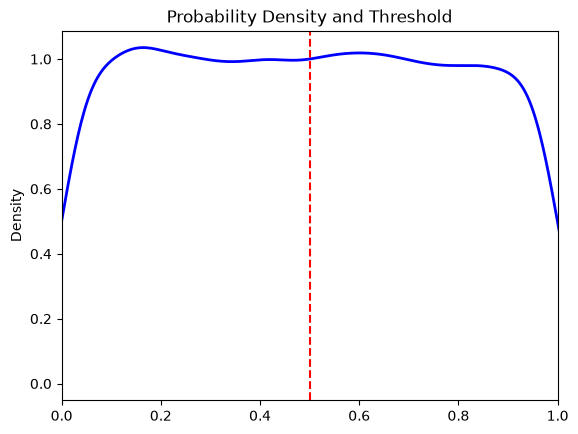

In [7]:
prob = df["probability"]
ax = prob.plot.density(bw_method="scott", color="blue", linestyle="-", linewidth=2)
ax.axvline(x=0.5, color="r", linestyle="--", linewidth=1.5)
ax.set_xlim((0, 1))
ax.set_title("Probability Density and Threshold")

## 4. Tune the threshold with `causalopt`

`causalopt` is the single entry point for threshold tuning. For the binary case we call it with `mode="binary"` and pass:

| Argument | Meaning |
| --- | --- |
| `df` | the DataFrame for the analysis |
| `outcomes` | the outcome column(s). The **first** is the *primary* outcome that drives the recommendation; the rest are carried along for the tradeoff |
| `score_cols` | the running variable — here the model score |
| `mode="binary"` | selects the single-threshold tuner |
| `threshold` | the current cutoff, in the original score scale (`0.5` here) |

In binary mode `causalopt` runs **both** analyses on one shared grid and returns a single dictionary:

- `results["optimum"]` — the recommendation and the optimum / conservative / aggressive thresholds for the primary outcome
- `results["frontier"]` — the tradeoff table with a welfare-gain column per outcome
- `results["current"]` — the current threshold, for reference
- `results["details"]` — the underlying RD estimates and prediction objects used by the plots


In [8]:
outcomes = ["completion", "revenue"]  # "completion" is the primary outcome
score_col = "probability"
threshold = 0.5

In [9]:
results = causalopt(df, outcomes, score_col, mode="binary", threshold=threshold)

## 5. How to read the results

A simple decision workflow:

1. **Is there an effect on the primary outcome?** Check the RD estimate for `completion`.
   - Not statistically significant → **stop and keep the current threshold**.
   - Significant → continue.
2. **Is there an effect on the secondary outcome(s)?** Check the RD estimate for `revenue`.
   - Not significant → adopt the recommended threshold from step 1.
   - Significant → there may be a tradeoff; continue.
3. **No tradeoff** (outcomes move in the same direction) → adopt the recommendation from step 1.
4. **Tradeoff** (outcomes move in opposite directions) → use the tradeoff frontier to pick the threshold that maximizes the primary-outcome gain subject to an acceptable loss on the secondary outcome.



### 5a. RD estimates at the current threshold

`results["details"]["rd_results"]` holds the bias-corrected RD estimates for the primary outcome (following Calonico, Cattaneo, and Titiunik, 2014). For a one-row-per-outcome summary (coef, se, CI, bandwidths `h`/`b`, obs on each side) covering **every** outcome, see `results["details"]["ate"]`; the full per-outcome RD objects are in `results["details"]["by_outcome"]`.

As expected from the simulation, the intervention **increases the completion rate** and **decreases average revenue** at the cutoff.

In [10]:
results["details"]["rd_results"]

{'tau': {'conventional': np.float64(0.28683521961375535),
  'bias_corrected': np.float64(0.279242830001436)},
 'se': {'conventional': np.float64(0.03502462727922198),
  'robust': np.float64(0.041510541841089585)},
 'ci': {'conventional': (np.float64(0.21818821157454116),
   np.float64(0.35548222765296955)),
  'bias_corrected': (np.float64(0.21059582196222182),
   np.float64(0.3478898380406502)),
  'robust': (np.float64(0.19788366301415744), np.float64(0.3606019969887146))},
 's_Y': array([1.]),
 'bandwidths': {'h_l': 0.16430850271293995,
  'h_r': 0.16430850271293995,
  'b_l': 0.255254332177061,
  'b_r': 0.255254332177061},
 'p': 1,
 'q': 2,
 'c': 0,
 'N': {'left': 5015, 'right': 4985},
 'N_h': {'left': np.int64(1615), 'right': np.int64(1693)},
 'N_b': {'left': np.int64(2536), 'right': np.int64(2590)},
 'coef_poly': {'conventional': {'left': array([[ 0.30313676],
          [-0.18738237]]),
   'right': array([[0.58997198],
          [1.93504966]])},
  'bias_corrected': {'left': array([[ 

### 5b. Visualize the discontinuity

`rdd_impact` plots the fitted polynomials on each side of the cutoff, together with the estimated jump and its confidence interval. It accepts the `causalopt` result directly.

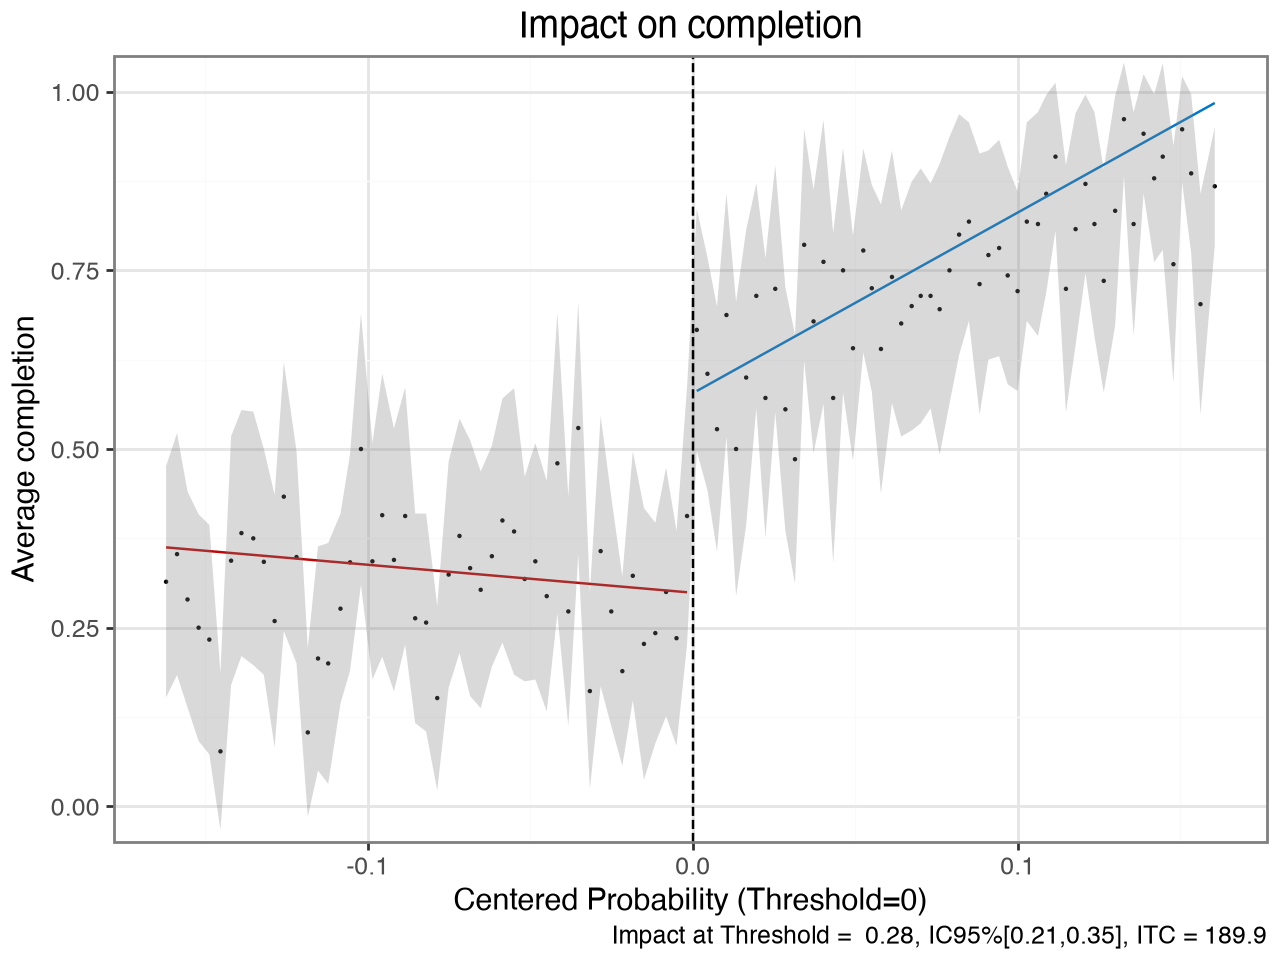

In [11]:
rdd_impact(results, "completion")

### 5c. Threshold recommendation

`results["optimum"]` reports:

1. **Thresholds** — the optimum, a conservative, and an aggressive threshold (in the original score scale).
2. **Additional Gain** — the extra expected gain in the primary outcome from moving to each of those thresholds.

The conservative/aggressive pair brackets the optimum using the confidence band, showing how sensitive the recommendation is to estimation noise.


In [12]:
results["optimum"]

{'Recommendation': 'Estimates are POSITIVE we should REDUCE the threshold',
 'Thresholds': {'Optimum': np.float64(0.40440371444206286),
  'Conservative': np.float64(0.4449771726241109),
  'Aggressive': np.float64(0.33789422410907277)},
 'Additional Gain': {'Optimum': np.float64(119.90533721559001),
  'Conservative': np.float64(51.495257533188486),
  'Aggressive': np.float64(287.4618095910984)}}

### 5d. Where the threshold should move

`plot_thresh` overlays the current threshold (black) with the optimum (blue), conservative (red), and aggressive (green) candidates on the fitted curves.

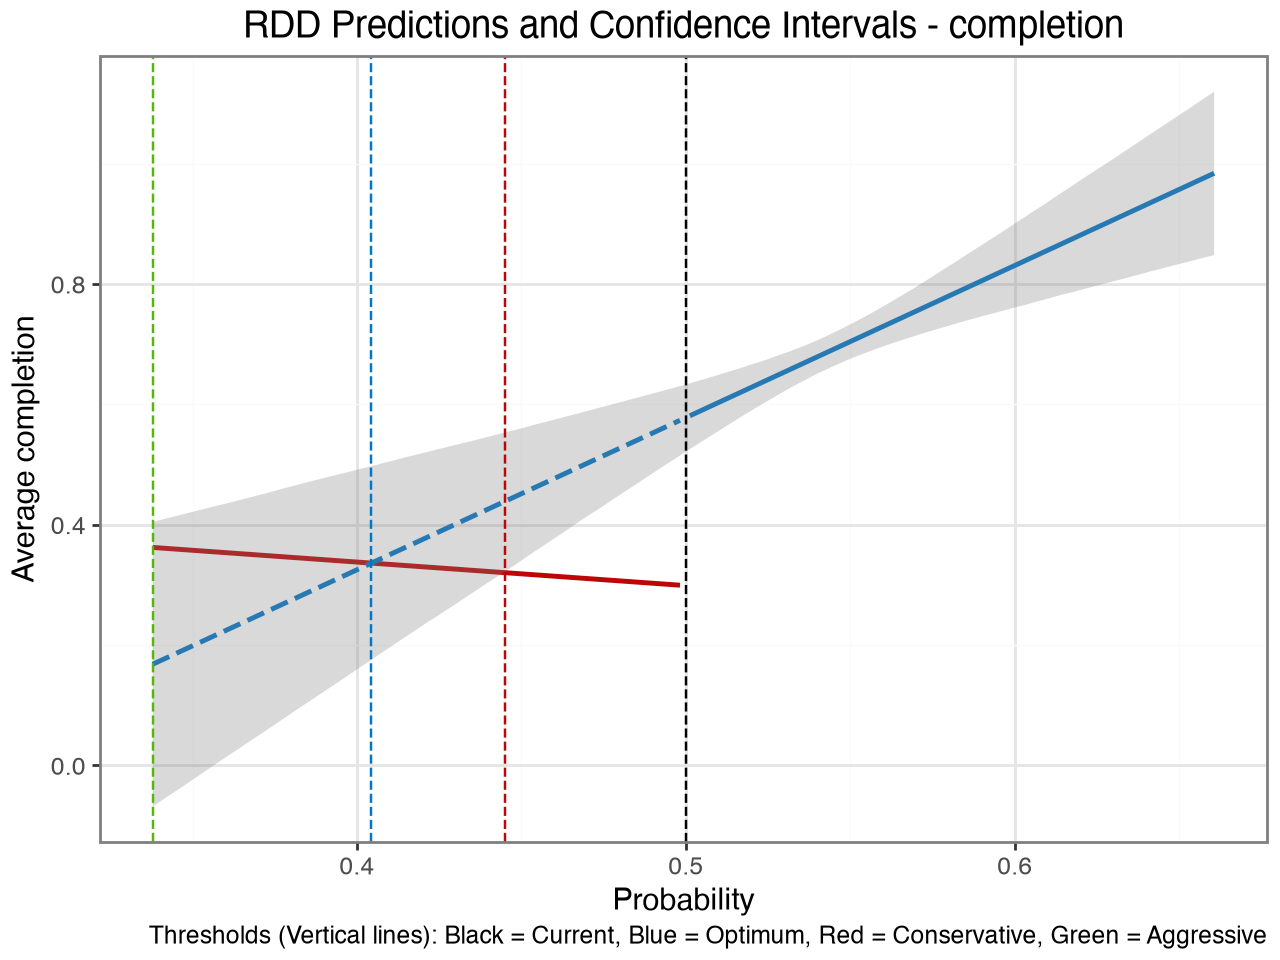

In [13]:
plot_thresh(results, "completion")

## 6. The tradeoff frontier

This is a textbook tradeoff: the intervention improves one metric (**completion**) at the expense of another (**revenue**).

Lowering the threshold treats more customers → more completions, but less revenue. Raising it does the opposite — protecting revenue but reducing volume. The right choice depends on how you value one outcome against the other.

We don't need a separate call for this: because we passed **both** outcomes to `causalopt`, the tradeoff table is already computed on the same shared grid as the recommendation above. `results["frontier"]` gives, for every candidate threshold, the expected **gain on each outcome** relative to the current cutoff (`x = 0`):

- `x` — the change in threshold (centered, so `x = 0` is the current cutoff)
- `gain_completion` — expected gain in completions at that threshold
- `gain_revenue` — expected gain in revenue at that threshold


In [14]:
frontier = results["frontier"]
frontier.head()

,x,n,p,gain_completion,gain_revenue
0,0.160588,3308,0.020556,-828.115550,15151.788655
1,0.156198,3308,0.011185,-800.905842,15213.580607
2,0.153326,3308,0.010580,-775.460530,15257.736193
3,0.150551,3308,0.011487,-748.142195,15290.679011
4,0.147869,3308,0.008767,-727.521100,15304.761096


### 6a. Plot the tradeoff

The two curves share an x-axis (the change in threshold) but use separate y-axes, since completion and revenue live on different scales. Reading them together shows how much revenue is given up for each additional completion as the threshold moves.

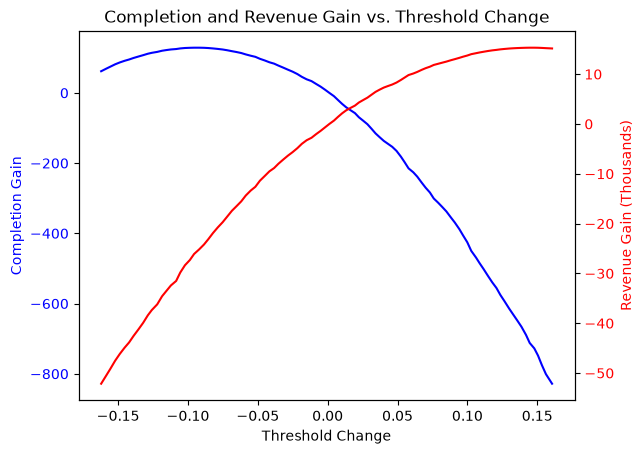

In [15]:
fig, ax1 = plt.subplots()

# Primary outcome: completion gain (left y-axis)
ax1.plot(
    frontier["x"],
    frontier["gain_completion"],
    color="blue",
    label="Completion Gain",
)
ax1.set_ylabel("Completion Gain", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Secondary outcome: revenue gain in thousands (right y-axis)
ax2 = ax1.twinx()
ax2.plot(
    frontier["x"],
    frontier["gain_revenue"] / 1000,
    color="red",
    label="Revenue Gain",
)
ax2.set_ylabel("Revenue Gain (Thousands)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

_ = ax1.set_xlabel("Threshold Change")
_ = plt.title("Completion and Revenue Gain vs. Threshold Change")